# 02 — AML Transaction Analysis
## Gaming Compliance & Risk Intelligence Platform

**Phase 5 deliverable.** Implements the 10 AML monitoring rules from
[`documentation/aml_monitoring_framework.md`](../documentation/aml_monitoring_framework.md),
generates scored alerts, and **validates them against the `Is_Laundering` ground-truth
label** (recall, precision, per-rule precision).

> Runs on the cleaned synthetic dataset from Phase 4. The rule logic mirrors the SQL
> in [`/sql/aml_rules`](../sql/aml_rules). Swapping in synthetic data does not change the rules.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data_processed/transactions_clean.csv", parse_dates=["Timestamp"])
df = df.reset_index().rename(columns={"index": "Transaction_ID"})
print(f"Loaded {len(df):,} transactions")
df[["Transaction_ID","Timestamp","From_Account","To_Account","Amount_Paid","Payment_Format","Is_Laundering"]].head()


Loaded 5,401 transactions


,Transaction_ID,Timestamp,From_Account,To_Account,Amount_Paid,Payment_Format,Is_Laundering
0,0,2024-04-01 00:41:12,ACC-1276,EXT-9002,755.98,Interac e-Transfer,0
1,1,2024-04-01 00:54:37,ACC-1266,EXT-9009,362.13,Prepaid Card,0
2,2,2024-04-01 02:00:00,ACC-1026,EXT-9030,9693.86,Credit Card,1
3,3,2024-04-01 02:05:11,ACC-1223,EXT-9020,293.93,Debit Card,0
4,4,2024-04-01 02:17:51,ACC-1064,EXT-9001,1019.93,Interac e-Transfer,0


## 1. Rule Definitions (metadata)

In [2]:
# Score -> severity bands per the framework
def severity(score):
    return ("Critical" if score >= 90 else "High" if score >= 70
            else "Medium" if score >= 40 else "Low")

RULES = {
 "AML-R01": dict(name="Large Transaction Detection",       score=75),
 "AML-R02": dict(name="Structuring / Smurfing",            score=80),
 "AML-R03": dict(name="Rapid Movement of Funds",           score=78),
 "AML-R04": dict(name="High Transaction Velocity",         score=60),
 "AML-R05": dict(name="Sub-Threshold Multiple Txns",       score=55),
 "AML-R06": dict(name="High-Risk Payment Format",          score=65),
 "AML-R07": dict(name="Unusual Activity Spike",            score=58),
 "AML-R08": dict(name="Dormant Account Reactivation",      score=62),
 "AML-R09": dict(name="Round-Number Large Transactions",   score=50),
 "AML-R10": dict(name="Counterparty Concentration",        score=72),
 "AML-R11": dict(name="Sanctions / Watchlist Match",       score=95),
}
for c, r in RULES.items():
    r["severity"] = severity(r["score"])
pd.DataFrame(RULES).T


,name,score,severity
AML-R01,Large Transaction Detection,75,High
AML-R02,Structuring / Smurfing,80,High
AML-R03,Rapid Movement of Funds,78,High
AML-R04,High Transaction Velocity,60,Medium
AML-R05,Sub-Threshold Multiple Txns,55,Medium
AML-R06,High-Risk Payment Format,65,Medium
AML-R07,Unusual Activity Spike,58,Medium
AML-R08,Dormant Account Reactivation,62,Medium
AML-R09,Round-Number Large Transactions,50,Medium
AML-R10,Counterparty Concentration,72,High


## 2. Rule Implementations\nEach rule returns the set of flagged `Transaction_ID`s.

In [3]:
def trailing_count(sub, window, time_col="Timestamp"):
    """Trailing rolling count (incl. self) within a time window, per pre-grouped frame."""
    s = sub.sort_values(time_col).set_index(time_col)
    return s.assign(_one=1)["_one"].rolling(window).sum()

flags = {}  # rule_code -> set of Transaction_ID

# R01 Large transaction
flags["AML-R01"] = set(df.loc[df.Amount_Paid >= 10000, "Transaction_ID"])

# R02 Structuring: >=3 txns in [9000,10000) per account within 7 days
band = df[(df.Amount_Paid >= 9000) & (df.Amount_Paid < 10000)].copy()
hit = []
for acct, sub in band.groupby("From_Account"):
    cnt = trailing_count(sub, "7D")
    ids = sub.sort_values("Timestamp").loc[cnt.values >= 3, "Transaction_ID"]
    hit += list(ids)
flags["AML-R02"] = set(hit)

# R03 Rapid movement: player deposit then withdrawal >=90% within 6h (same player)
dep = df[df.Transaction_Type == "Deposit"][["From_Account","Timestamp","Amount_Paid"]]
wd = df[df.Transaction_Type == "Withdrawal"][["Transaction_ID","From_Account","Timestamp","Amount_Paid"]]
m = wd.merge(dep, on="From_Account", suffixes=("_out","_in"))
m = m[(m.Timestamp_out > m.Timestamp_in) &
      (m.Timestamp_out <= m.Timestamp_in + pd.Timedelta("6h")) &
      (m.Amount_Paid_out >= 0.90 * m.Amount_Paid_in)]
flags["AML-R03"] = set(m.Transaction_ID)

# R04 High velocity: >=8 txns per account within 24h
hit = []
for acct, sub in df.groupby("From_Account"):
    cnt = trailing_count(sub, "24H")
    hit += list(sub.sort_values("Timestamp").loc[cnt.values >= 8, "Transaction_ID"])
flags["AML-R04"] = set(hit)

# R05 Sub-threshold multiple: >=5 txns < 10,000 per account per calendar day
small = df[df.Amount_Paid < 10000].copy()
small["day"] = small.Timestamp.dt.date
g = small.groupby(["From_Account","day"])["Transaction_ID"].transform("size")
flags["AML-R05"] = set(small.loc[g >= 5, "Transaction_ID"])

# R06 High-risk payment method (Crypto / Prepaid Card) >= 5,000
flags["AML-R06"] = set(df.loc[df.Payment_Format.isin(["Crypto","Prepaid Card"]) & (df.Amount_Paid >= 5000),
                              "Transaction_ID"])

# R07 Unusual spike: daily total >= 5x account median daily total and >= 5,000
df["day"] = df.Timestamp.dt.date
daily = df.groupby(["From_Account","day"])["Amount_Paid"].sum().reset_index(name="day_total")
medn = daily.groupby("From_Account")["day_total"].median().rename("median_day")
daily = daily.merge(medn, on="From_Account")
spike_days = daily[(daily.day_total >= 5000) & (daily.median_day > 0) &
                   (daily.day_total >= 5 * daily.median_day)][["From_Account","day"]]
flags["AML-R07"] = set(df.merge(spike_days, on=["From_Account","day"]).Transaction_ID)

# R08 Dormant reactivation: gap >= 30 days then >= 5,000
hit = []
for acct, sub in df.sort_values("Timestamp").groupby("From_Account"):
    gap = sub.Timestamp.diff().dt.days
    hit += list(sub.loc[(gap >= 30) & (sub.Amount_Paid >= 5000), "Transaction_ID"])
flags["AML-R08"] = set(hit)

# R09 Round-number large: >= 10,000 and exact multiple of 1,000
flags["AML-R09"] = set(df.loc[(df.Amount_Paid >= 10000) & (df.Amount_Paid % 1000 == 0),
                              "Transaction_ID"])

# R10 Counterparty concentration: >=4 txns to same payee totaling >= 20,000
pair = df.groupby(["From_Account","To_Account"]).agg(
    cnt=("Transaction_ID","size"), tot=("Amount_Paid","sum")).reset_index()
hot = pair[(pair.cnt >= 4) & (pair.tot >= 20000)][["From_Account","To_Account"]]
flags["AML-R10"] = set(df.merge(hot, on=["From_Account","To_Account"]).Transaction_ID)

# R11 Sanctions / watchlist match: any transaction by a sanctioned/watchlisted account
flags["AML-R11"] = set(df.loc[df.Sanctions_Flag == 1, "Transaction_ID"])

for c in RULES:
    print(f"{c} {RULES[c]['name']:<34} -> {len(flags[c]):>4} matches")


/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykern

/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykern

/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykern

/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykern

/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykern

/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykernel_84166/1770100209.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return s.assign(_one=1)["_one"].rolling(window).sum()
/var/folders/hn/h1r49vs14b9fpxq3q1qr5t8c0000gn/T/ipykern

AML-R01 Large Transaction Detection        ->  101 matches
AML-R02 Structuring / Smurfing             ->   68 matches
AML-R03 Rapid Movement of Funds            ->   64 matches
AML-R04 High Transaction Velocity          ->   29 matches
AML-R05 Sub-Threshold Multiple Txns        ->   89 matches
AML-R06 High-Risk Payment Format           ->   75 matches
AML-R07 Unusual Activity Spike             ->  418 matches
AML-R08 Dormant Account Reactivation       ->    6 matches
AML-R09 Round-Number Large Transactions    ->   15 matches
AML-R10 Counterparty Concentration         ->   44 matches
AML-R11 Sanctions / Watchlist Match        ->  121 matches


## 3. Generate Alerts (Fact_AML_Alerts)

In [4]:
alert_rows = []
for code, ids in flags.items():
    for tid in ids:
        alert_rows.append(dict(Transaction_ID=tid, Rule_Code=code,
                               Rule_Name=RULES[code]["name"],
                               Risk_Score=RULES[code]["score"],
                               Severity=RULES[code]["severity"],
                               Is_Escalated=int(RULES[code]["score"] >= 70)))
alerts = pd.DataFrame(alert_rows).merge(
    df[["Transaction_ID","From_Account","Timestamp","Amount_Paid","Is_Laundering"]],
    on="Transaction_ID", how="left")
print(f"Total alerts (transaction x rule): {len(alerts):,}")
print(f"Distinct transactions flagged: {alerts.Transaction_ID.nunique():,}")
print(f"Auto-escalated alerts: {alerts.Is_Escalated.sum():,}")
alerts.head()


Total alerts (transaction x rule): 1,030
Distinct transactions flagged: 559
Auto-escalated alerts: 398


,Transaction_ID,Rule_Code,Rule_Name,Risk_Score,Severity,Is_Escalated,From_Account,Timestamp,Amount_Paid,Is_Laundering
0,3079,AML-R01,Large Transaction Detection,75,High,1,ACC-1012,2024-05-22 15:58:50,42565.74,1
1,3595,AML-R01,Large Transaction Detection,75,High,1,ACC-1128,2024-05-30 17:00:00,12039.33,1
2,1037,AML-R01,Large Transaction Detection,75,High,1,ACC-1248,2024-04-18 04:00:00,14737.60,1
3,4109,AML-R01,Large Transaction Detection,75,High,1,ACC-1194,2024-06-08 03:52:22,22536.17,1
4,3600,AML-R01,Large Transaction Detection,75,High,1,ACC-1128,2024-05-30 19:00:00,11543.36,1


In [5]:
alerts.to_csv("../data_processed/aml_alerts.csv", index=False)
print("Exported -> ../data_processed/aml_alerts.csv")


Exported -> ../data_processed/aml_alerts.csv


## 4. Validation vs Ground Truth (`Is_Laundering`)

In [6]:
flagged_ids = set(alerts.Transaction_ID)
df["Flagged"] = df.Transaction_ID.isin(flagged_ids).astype(int)

TP = int(((df.Is_Laundering == 1) & (df.Flagged == 1)).sum())
FP = int(((df.Is_Laundering == 0) & (df.Flagged == 1)).sum())
FN = int(((df.Is_Laundering == 1) & (df.Flagged == 0)).sum())
TN = int(((df.Is_Laundering == 0) & (df.Flagged == 0)).sum())

recall = TP / (TP + FN) if (TP+FN) else 0
precision = TP / (TP + FP) if (TP+FP) else 0
f1 = 2*precision*recall/(precision+recall) if (precision+recall) else 0

print(f"Confusion matrix:  TP={TP}  FP={FP}  FN={FN}  TN={TN}")
print(f"Recall   : {recall:.1%}  (of true laundering, how much we caught)")
print(f"Precision: {precision:.1%}  (of flagged, how much was truly laundering)")
print(f"F1 score : {f1:.3f}")


Confusion matrix:  TP=486  FP=73  FN=3  TN=4839
Recall   : 99.4%  (of true laundering, how much we caught)
Precision: 86.9%  (of flagged, how much was truly laundering)
F1 score : 0.927


In [7]:
# Per-rule precision: how clean is each rule's output
rows = []
for code in RULES:
    sub = alerts[alerts.Rule_Code == code]
    if len(sub):
        rows.append(dict(Rule=code, Name=RULES[code]["name"], Alerts=len(sub),
                         True_Laundering=int(sub.Is_Laundering.sum()),
                         Precision=f"{sub.Is_Laundering.mean():.0%}"))
per_rule = pd.DataFrame(rows)
per_rule


,Rule,Name,Alerts,True_Laundering,Precision
0,AML-R01,Large Transaction Detection,101,101,100%
1,AML-R02,Structuring / Smurfing,68,68,100%
2,AML-R03,Rapid Movement of Funds,64,33,52%
3,AML-R04,High Transaction Velocity,29,29,100%
4,AML-R05,Sub-Threshold Multiple Txns,89,86,97%
5,AML-R06,High-Risk Payment Format,75,71,95%
6,AML-R07,Unusual Activity Spike,418,377,90%
7,AML-R08,Dormant Account Reactivation,6,6,100%
8,AML-R09,Round-Number Large Transactions,15,15,100%
9,AML-R10,Counterparty Concentration,44,42,95%


### Chart: alerts by rule

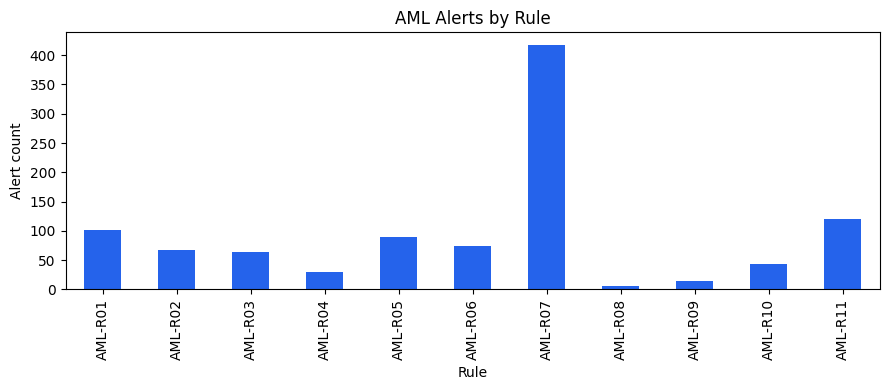

In [8]:
by_rule = alerts.Rule_Code.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9,4))
by_rule.plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("AML Alerts by Rule"); ax.set_xlabel("Rule"); ax.set_ylabel("Alert count")
plt.tight_layout(); plt.show()


### Chart: alerts by severity

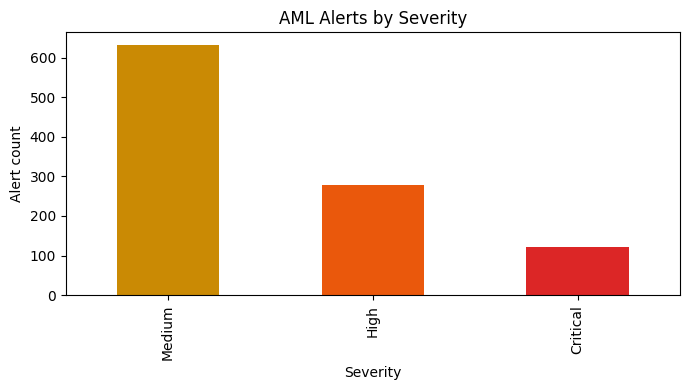

In [9]:
order = ["Low","Medium","High","Critical"]
by_sev = alerts.Severity.value_counts().reindex(order).dropna()
colors = {"Low":"#16a34a","Medium":"#ca8a04","High":"#ea580c","Critical":"#dc2626"}
fig, ax = plt.subplots(figsize=(7,4))
by_sev.plot(kind="bar", ax=ax, color=[colors[s] for s in by_sev.index])
ax.set_title("AML Alerts by Severity"); ax.set_xlabel("Severity"); ax.set_ylabel("Alert count")
plt.tight_layout(); plt.show()


### Chart: confusion matrix

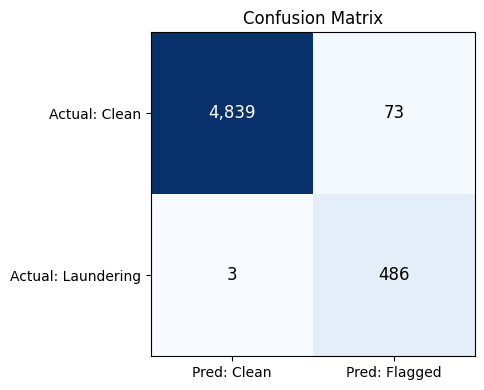

In [10]:
cm = np.array([[TN, FP],[FN, TP]])
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_xticklabels(["Pred: Clean","Pred: Flagged"])
ax.set_yticks([0,1]); ax.set_yticklabels(["Actual: Clean","Actual: Laundering"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=12)
ax.set_title("Confusion Matrix"); plt.tight_layout(); plt.show()


## 5. Customer Risk Rating
A customer-level risk rating combining sanctions/PEP status with alert behaviour —
the kind of CDD output a compliance team maintains per player.

In [11]:
acct = df.groupby("From_Account").agg(
    PEP=("PEP_Flag","max"), Sanctions=("Sanctions_Flag","max"),
    Txns=("Transaction_ID","size")).reset_index()
alert_cnt = alerts.groupby("From_Account").Transaction_ID.nunique().rename("Alerted_Txns")
acct = acct.merge(alert_cnt, on="From_Account", how="left").fillna({"Alerted_Txns":0})

def risk_rating(r):
    if r.Sanctions == 1:               return "Critical"
    if r.PEP == 1 or r.Alerted_Txns >= 3: return "High"
    if r.Alerted_Txns >= 1:            return "Medium"
    return "Low"
acct["Risk_Rating"] = acct.apply(risk_rating, axis=1)
acct.to_csv("../data_processed/account_risk_ratings.csv", index=False)

print("Accounts by risk rating:")
print(acct.Risk_Rating.value_counts().reindex(["Critical","High","Medium","Low"]).to_string())
acct.sort_values(["Sanctions","PEP","Alerted_Txns"], ascending=False).head()


Accounts by risk rating:
Risk_Rating
Critical      5
High         68
Medium       74
Low         159


,From_Account,PEP,Sanctions,Txns,Alerted_Txns,Risk_Rating
10,ACC-1010,0,1,35,35.0,Critical
91,ACC-1091,0,1,26,26.0,Critical
195,ACC-1195,0,1,22,22.0,Critical
212,ACC-1212,0,1,22,22.0,Critical
141,ACC-1141,0,1,16,16.0,Critical


## 6. Summary

- The rule set is **explainable** — every alert traces to a named typology with a
  documented threshold, as required in regulated AML monitoring.
- Validation against ground truth quantifies the **detection vs. false-positive**
  trade-off that compliance teams tune in practice.
- Escalated alerts (score >= 70) feed **Phase 6 — STR Workflow**, where they become
  investigation cases.

**Output:** `data_processed/aml_alerts.csv` (one row per transaction x rule match).
